# **Notebook: Clustering the data**

## Table of Contents
* [Importing Libraries](#importing_libraries)
* [Data Loading](#loading_data)
* [Calculate Distances](#calculate_distances)
    * [Helper Functions](#helper_function)
    * [Distance to Geometry Points](#distance_to_geometry_points)
    * [Distance to Geometry Polygons](#distance_to_geometry_polygons)
    * [Compute Final Distances](#compute_final_distances)
* [Other Factors](#other_factors)
    * [Air Pollution](#air_pollution)
* [Quality of Life Index](#compute_qol_index)


### Imports <a class="anchor" id="importing_libraries"></a>

In [53]:
import geopandas as gpd
import osmnx as ox
import numpy as np
import networkx as nx
import pandas as pd
from shapely.ops import unary_union
import contextily as cx
import matplotlib.pyplot as plt
from tqdm import tqdm
import h3
import pandana
from shapely import Polygon, LineString
import h3
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from rasterio.plot import show
import rioxarray as rxr
import contextily as cx 
import seaborn as sns
import pandas as pd
import esda
from pysal.lib import weights
from splot.esda import (
    moran_scatterplot, lisa_cluster, plot_local_autocorrelation, plot_moran
)
from splot.libpysal import plot_spatial_weights
import geopandas as gpd
import numpy as np
import contextily as cx
import matplotlib.pyplot as plt

%matplotlib inline
ox.__version__

'1.9.4'

## Data Loading <a class="anchor" id="loading_data"></a>

In [54]:
CRS = "EPSG:25832"
CRS_ORIGINAL = "EPSG:4326"

In [55]:
df = gpd.read_file("../data/clean_data/qol_index.gpkg")

assert CRS == df.crs, "mismatched crs"

In [56]:
df.crs

<Projected CRS: EPSG:25832>
Name: ETRS89 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 6°E and 12°E: Austria; Belgium; Denmark - onshore and offshore; Germany - onshore and offshore; Norway including - onshore and offshore; Spain - offshore.
- bounds: (6.0, 38.76, 12.01, 84.33)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [57]:
df.to_crs(CRS_ORIGINAL, inplace=True)

In [58]:
df.head()

,osm_id,amenity,school,bus,train,hospital,clinic,green_area,NO2,qol_index,scaled_qol_index,geometry
0,23540747,apartments,5,3,3,1,2,5,4,0.602281,2.800003,POINT (12.53998 55.69419)
1,24508264,apartments,2,2,1,1,1,5,4,0.475938,2.212636,POINT (12.49018 55.65712)
2,24508268,apartments,2,2,1,1,1,5,4,0.475938,2.212636,POINT (12.48962 55.65687)
3,24508270,apartments,2,3,1,1,1,5,3,0.413078,1.920399,POINT (12.48907 55.65661)
4,24513387,apartments,2,5,1,1,1,5,4,0.498857,2.319188,POINT (12.49313 55.64761)


# Aggregation: h3

In [59]:
h3_level = 9

df_agg = df.copy()
df_agg['h3'] = df_agg.apply(lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, h3_level), axis=1)

df_agg.head()

,osm_id,amenity,school,bus,train,hospital,clinic,green_area,NO2,qol_index,scaled_qol_index,geometry,h3
0,23540747,apartments,5,3,3,1,2,5,4,0.602281,2.800003,POINT (12.53998 55.69419),891f0583553ffff
1,24508264,apartments,2,2,1,1,1,5,4,0.475938,2.212636,POINT (12.49018 55.65712),891f0598d3bffff
2,24508268,apartments,2,2,1,1,1,5,4,0.475938,2.212636,POINT (12.48962 55.65687),891f0598d3bffff
3,24508270,apartments,2,3,1,1,1,5,3,0.413078,1.920399,POINT (12.48907 55.65661),891f0598d3bffff
4,24513387,apartments,2,5,1,1,1,5,4,0.498857,2.319188,POINT (12.49313 55.64761),891f059898bffff


In [60]:
df_agg['h3'].nunique()

843

In [61]:
mean = df_agg.groupby(['h3']).scaled_qol_index.mean().to_frame('mean').reset_index()
mean.shape

(843, 2)

In [62]:
def add_geometry(row):
    points = h3.cell_to_boundary(row['h3'])
    return h3.LatLngPoly(points)

mean['geometry'] = mean.apply(add_geometry, axis=1)
mean.head()

,h3,mean,geometry
0,891f058000bffff,2.608619,<LatLngPoly: [6]>
1,891f0580043ffff,3.418296,<LatLngPoly: [6]>
2,891f0580047ffff,2.882679,<LatLngPoly: [6]>
3,891f058004bffff,4.233244,<LatLngPoly: [6]>
4,891f058004fffff,4.014327,<LatLngPoly: [6]>


In [63]:
gdf = gpd.GeoDataFrame(mean, crs=CRS_ORIGINAL)

In [64]:
gdf.explore(column='mean', legend=True)

<Axes: >

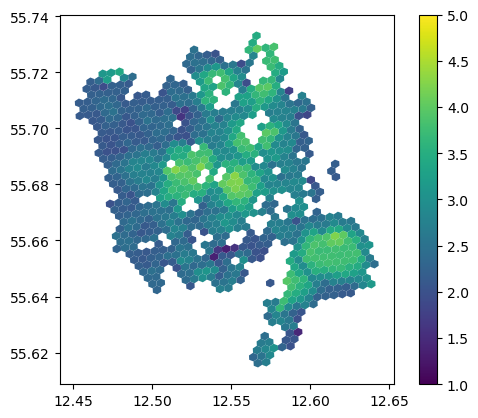

In [65]:
gdf.plot(column='mean', legend=True, vmin=1, vmax=5)

# Spatial Autocorrelation

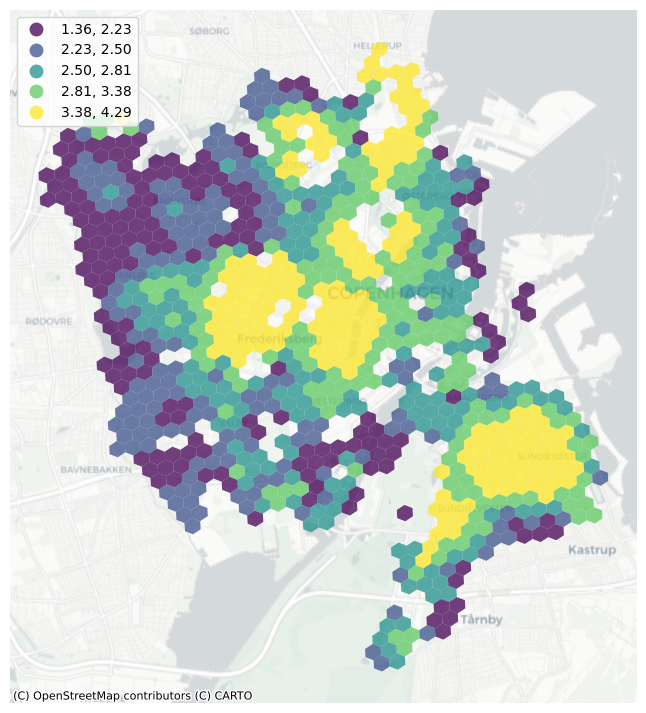

In [66]:
f, ax = plt.subplots(1, figsize=(9, 9))
gdf.plot(
    column="mean",
    cmap="viridis",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
cx.add_basemap(
    ax,
    crs=gdf.crs,
    source=cx.providers.CartoDB.Positron
)
ax.set_axis_off()

In [67]:
gdf

,h3,mean,geometry
0,891f058000bffff,2.608619,"POLYGON ((12.62305 55.66753, 12.62320 55.66598..."
1,891f0580043ffff,3.418296,"POLYGON ((12.61534 55.66467, 12.61549 55.66313..."
2,891f0580047ffff,2.882679,"POLYGON ((12.62063 55.66503, 12.62078 55.66348..."
3,891f058004bffff,4.233244,"POLYGON ((12.61292 55.66218, 12.61307 55.66063..."
4,891f058004fffff,4.014327,"POLYGON ((12.61821 55.66253, 12.61836 55.66098..."
...,...,...,...
838,891f059adabffff,2.285967,"POLYGON ((12.46162 55.71041, 12.46177 55.70886..."
839,891f059adafffff,2.390903,"POLYGON ((12.46691 55.71077, 12.46706 55.70922..."
840,891f059adb3ffff,2.112835,"POLYGON ((12.46115 55.71505, 12.46131 55.71350..."
841,891f059adb7ffff,1.936370,"POLYGON ((12.46645 55.71541, 12.46660 55.71386..."


In [68]:
# Create the spatial weights matrix
w = weights.Queen.from_dataframe(gdf, ids="h3")

c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 891f0581573ffff.
  warnings.warn(message)


In [69]:
w.islands[0]

'891f0581573ffff'

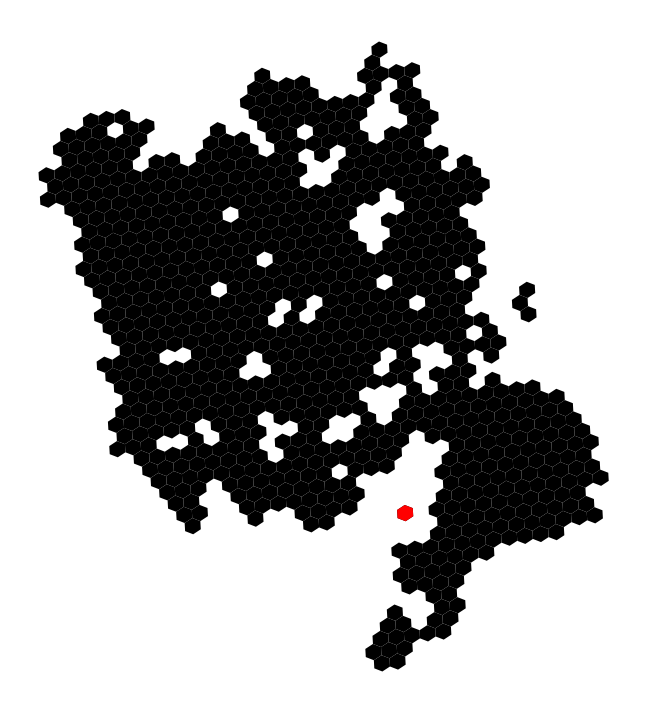

In [70]:
# explore islands from warning
ax = gdf.plot(color='k', figsize=(9, 9))
# gdf.loc[w.islands, :].plot(color='red', ax=ax)
gdf.loc[gdf['h3'] == w.islands[0]].plot(color='red', ax=ax) # there is only one island
ax.set_axis_off()

In [71]:
rows = gdf.loc[gdf['h3'] == w.islands[0]].index
# gdf_test = gdf.copy()
print(gdf.shape)
gdf.drop(rows, inplace=True)
print(gdf.shape)
# print(gdf_test.shape)

(843, 3)
(842, 3)


In [72]:
# Now that islands are removed, reset the weights
w = weights.Queen.from_dataframe(gdf, ids="h3")

c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\libpysal\weights\weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  warnings.warn(message)


In [73]:
# w.component_labels

gdf['component'] = w.component_labels
gdf.component.unique()

array([0, 1])

In [74]:
# gdf[gdf['component']==1]

# rows = gdf.loc[gdf['h3'] == w.islands[0]].index
rows2 = gdf[gdf['component']==1].index

# gdf_test = gdf.copy()
gdf.drop(rows2, inplace=True)
print(gdf.shape)
# print(gdf.shape)
# gdf.drop(rows, inplace=True)
# print(gdf.shape)

(839, 4)


In [75]:
# Now that islands are removed, reset the weights
w = weights.Queen.from_dataframe(gdf, ids="h3")

In [76]:
# Row standardize the matrix
w.transform = 'R'

c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\splot\_viz_libpysal_mpl.py:121: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids_shp = gdf.centroid.values
c:\Users\mespi\Desktop\GeoSpatial_DS\.pixi\envs\default\lib\site-packages\splot\_viz_libpysal_mpl.py:164: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.centroid.plot(ax=ax, **node_kws)


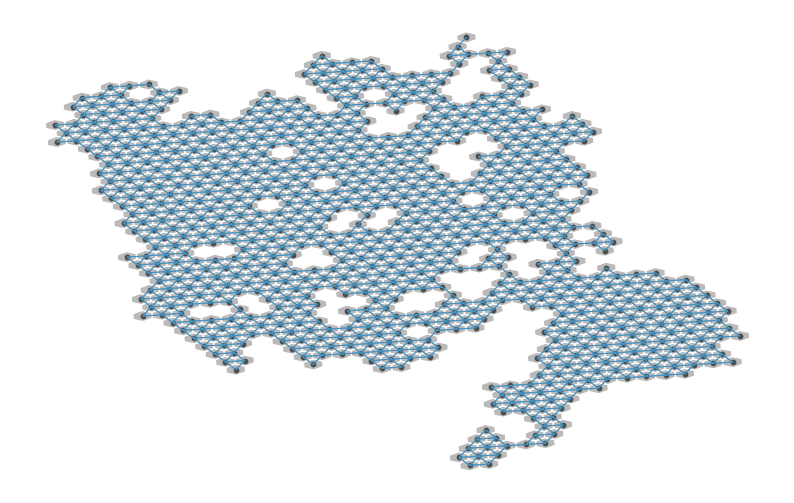

In [77]:
# This plot might not be relevant

# Connectivity graph
plot_spatial_weights(w, gdf, indexed_on="h3"); 


In [78]:
gdf

,h3,mean,geometry,component
0,891f058000bffff,2.608619,"POLYGON ((12.62305 55.66753, 12.62320 55.66598...",0
1,891f0580043ffff,3.418296,"POLYGON ((12.61534 55.66467, 12.61549 55.66313...",0
2,891f0580047ffff,2.882679,"POLYGON ((12.62063 55.66503, 12.62078 55.66348...",0
3,891f058004bffff,4.233244,"POLYGON ((12.61292 55.66218, 12.61307 55.66063...",0
4,891f058004fffff,4.014327,"POLYGON ((12.61821 55.66253, 12.61836 55.66098...",0
...,...,...,...,...
838,891f059adabffff,2.285967,"POLYGON ((12.46162 55.71041, 12.46177 55.70886...",0
839,891f059adafffff,2.390903,"POLYGON ((12.46691 55.71077, 12.46706 55.70922...",0
840,891f059adb3ffff,2.112835,"POLYGON ((12.46115 55.71505, 12.46131 55.71350...",0
841,891f059adb7ffff,1.936370,"POLYGON ((12.46645 55.71541, 12.46660 55.71386...",0


In [79]:
gdf['w_mean'] = weights.lag_spatial(w, gdf['mean']) # we pass the weights object and the column with values to base the spatial lag on
# with standardized weights we can compute the lag

In [80]:
# mean of hexagon and the mean of neighbouring hexagons
gdf[['h3', 'mean', 'w_mean']].head()

,h3,mean,w_mean
0,891f058000bffff,2.608619,2.726942
1,891f0580043ffff,3.418296,3.352356
2,891f0580047ffff,2.882679,3.109689
3,891f058004bffff,4.233244,3.800178
4,891f058004fffff,4.014327,3.611032


In [81]:
# Standardize the variables
gdf['mean_std'] = ( 
    gdf['mean'] - gdf['mean'].mean()
) / gdf['mean'].std()

In [82]:
gdf['w_mean_std'] = weights.lag_spatial(w, gdf['mean_std'])

In [83]:
gdf[['h3', 'mean', 'w_mean','mean_std','w_mean_std']].head()
# This is for the hotspots?

,h3,mean,w_mean,mean_std,w_mean_std
0,891f058000bffff,2.608619,2.726942,-0.290431,-0.087276
1,891f0580043ffff,3.418296,3.352356,1.099752,0.986535
2,891f0580047ffff,2.882679,3.109689,0.180119,0.569885
3,891f058004bffff,4.233244,3.800178,2.498985,1.755427
4,891f058004fffff,4.014327,3.611032,2.123112,1.430671


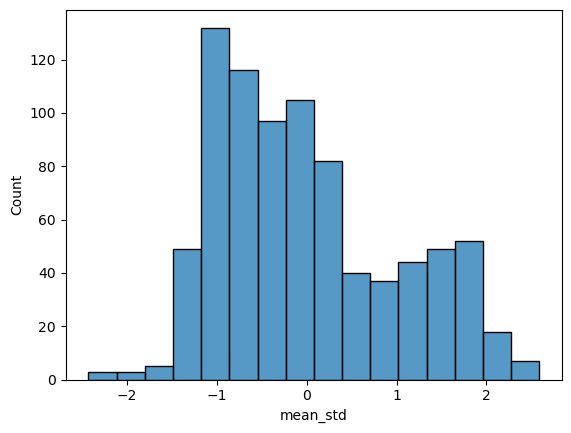

In [84]:
sns.histplot(gdf.mean_std);
# Long right tail, so not a lot with high mean. 

## Moran's I - Global

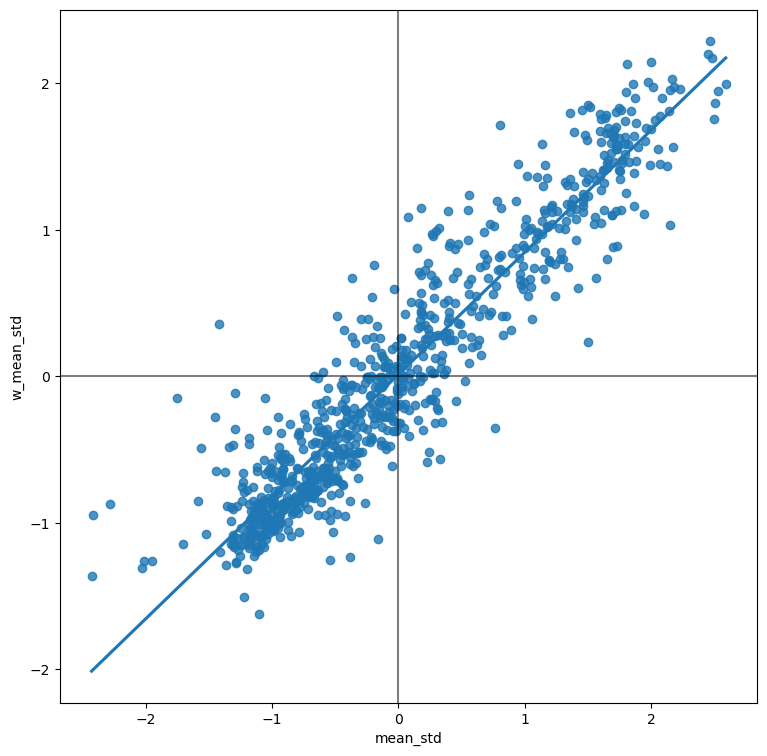

In [85]:
# Moran plot

# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sns.regplot(x='mean_std', y='w_mean_std', data=gdf, ci=None) # regression plot from seaborn where we plot the x and y against each other. the ci is the confidence interval
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5) # divide into four quardrants
plt.axhline(0, c='k', alpha=0.5) # divide into four quardrants
# Display
plt.show()
# does the plot manually

In [86]:
mi = esda.Moran(gdf['mean'], w)
mi.I

0.8340216645880492

In [87]:
# p value of Moran's I
mi.p_sim

0.001

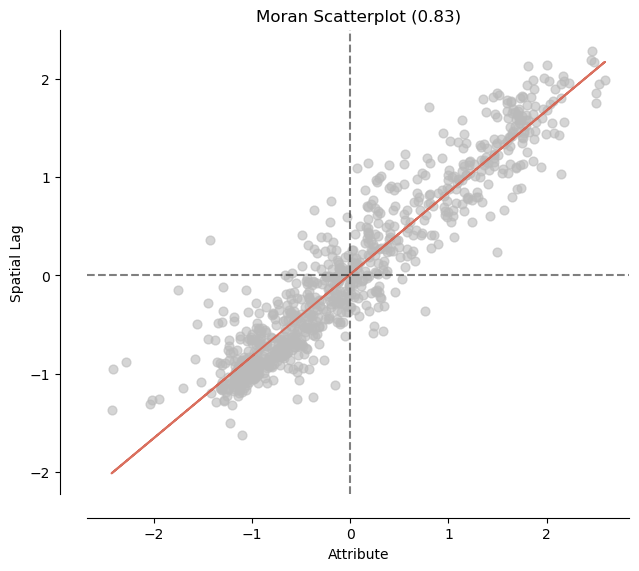

In [88]:
moran_scatterplot(mi);

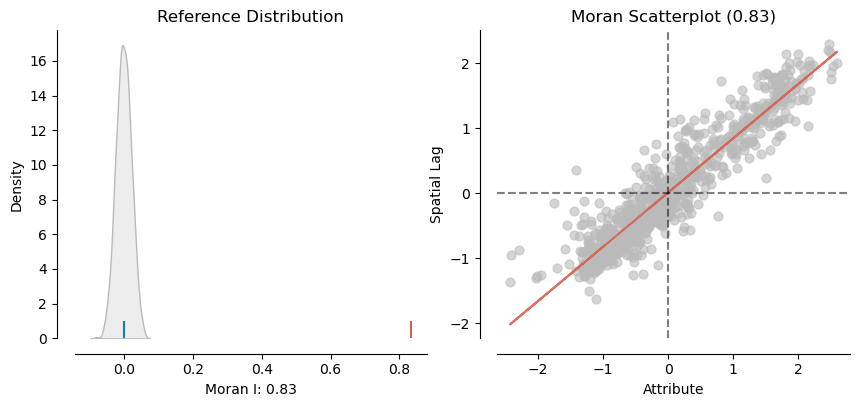

In [89]:
plot_moran(mi);

## Moran's I - Local

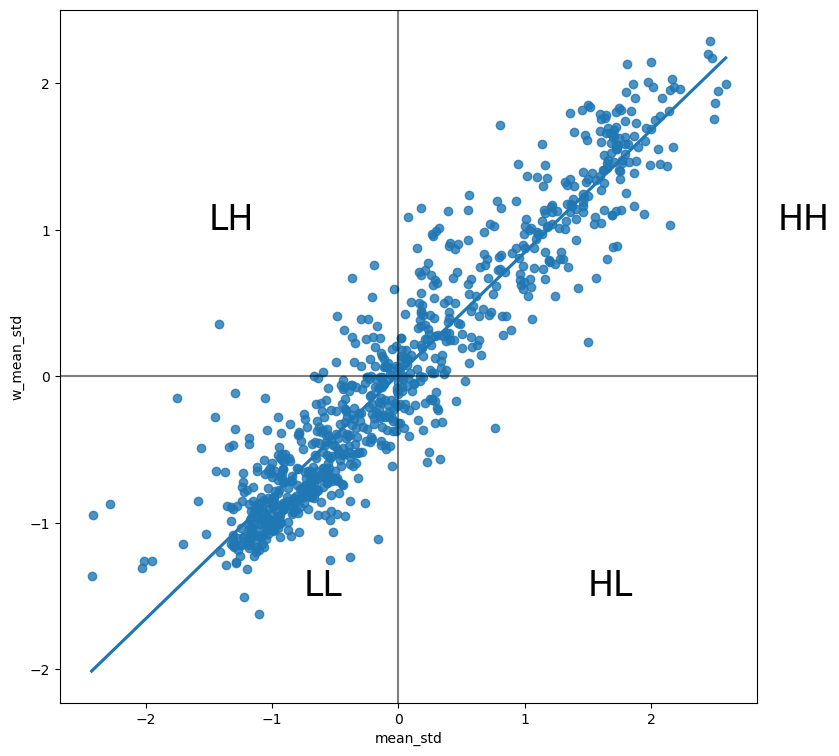

In [90]:
# find local hotspots - HH
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot values
sns.regplot(x='mean_std', y='w_mean_std', data=gdf, ci=None)
# Add vertical and horizontal lines
plt.axvline(0, c='k', alpha=0.5)
plt.axhline(0, c='k', alpha=0.5)
plt.text(3, 1, "HH", fontsize=25)
plt.text(1.5, -1.5, "HL", fontsize=25)
plt.text(-1.5, 1, "LH", fontsize=25)
plt.text(-0.75, -1.5, "LL", fontsize=25)
# Display
plt.show()

In [91]:
lisa = esda.Moran_Local(gdf['mean'], w) # identify the statistical significant clusters

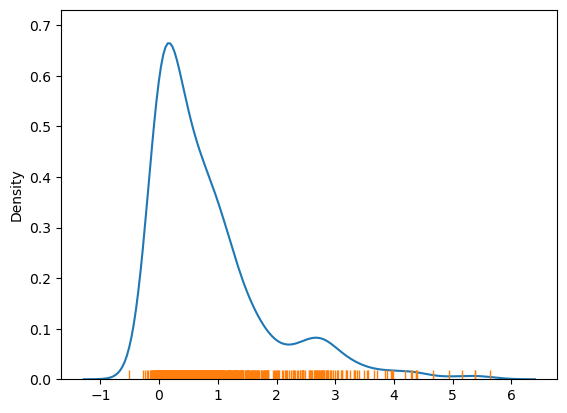

In [92]:
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);
# kernel density plot of the hexagons
# tail to the right tells us that some spatial units have very high Moran's I, there are also some to the left
# There are some outliers (possibly the 3 unit disconnected component) that have much higer Moran's I than all else

In [93]:
print('Sum of local vlaues: ', lisa.Is.sum()) # sum of the local values
print('Sum of global values: ', mi.I*len(gdf)) # almost the same as above

Sum of local vlaues:  698.9101549247853
Sum of global values:  699.7441765893733


In [94]:
# Break observations into significant or not
gdf['significant'] = lisa.p_sim < 0.05 # .p_sim is p score for LISA values. Stored in new column
# Store the quadrant they belong to
gdf['quadrant'] = lisa.q # quardrant 1 through 4

The correspondence between the numbers in the variable and the actual quadrants is as follows:

* 1: HH
* 2: LH
* 3: LL
* 4: HL

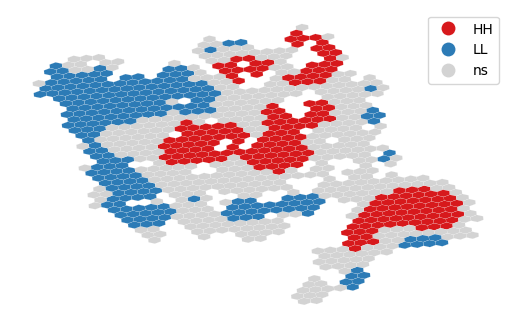

In [95]:
lisa_cluster(lisa, gdf, p=0.05);

ValueError: aspect must be finite and positive 

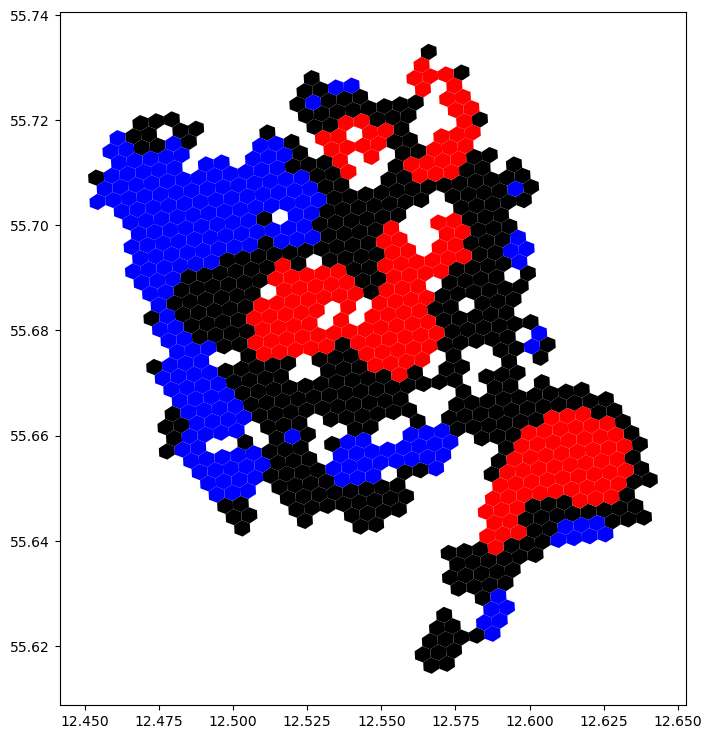

In [96]:
# Same, but more control over the colours
# Needs a legend

# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(9, 9))
# Plot insignificant clusters
ns = gdf.loc[gdf['significant']==False, 'geometry']
ns.plot(ax=ax, color='k', label='ns')
# Plot HH clusters
hh = gdf.loc[(gdf['quadrant']==1) & (gdf['significant']==True), 'geometry']
hh.plot(ax=ax, color='red', label='hh')
# Plot LL clusters
ll = gdf.loc[(gdf['quadrant']==3) & (gdf['significant']==True), 'geometry']
ll.plot(ax=ax, color='blue', label='ll')
# Plot LH clusters
lh = gdf.loc[(gdf['quadrant']==2) & (gdf['significant']==True), 'geometry']
lh.plot(ax=ax, color='#83cef4', label='lh')
# Plot HL clusters
hl = gdf.loc[(gdf['quadrant']==4) & (gdf['significant']==True), 'geometry']
hl.plot(ax=ax, color='#e59696', label='hl')
# Style and draw
f.suptitle('LISA for Quality of Life in Copenhagen & Frederiksberg', size=13)
f.set_facecolor('0.75')
ax.set_axis_off()
plt.legend([ns, hh, ll, lh, hl],['ns', 'hh', 'll', 'lh', 'hl'])
# ax.legend(handles=[ns, hh, ll, lh, hl])
plt.show()


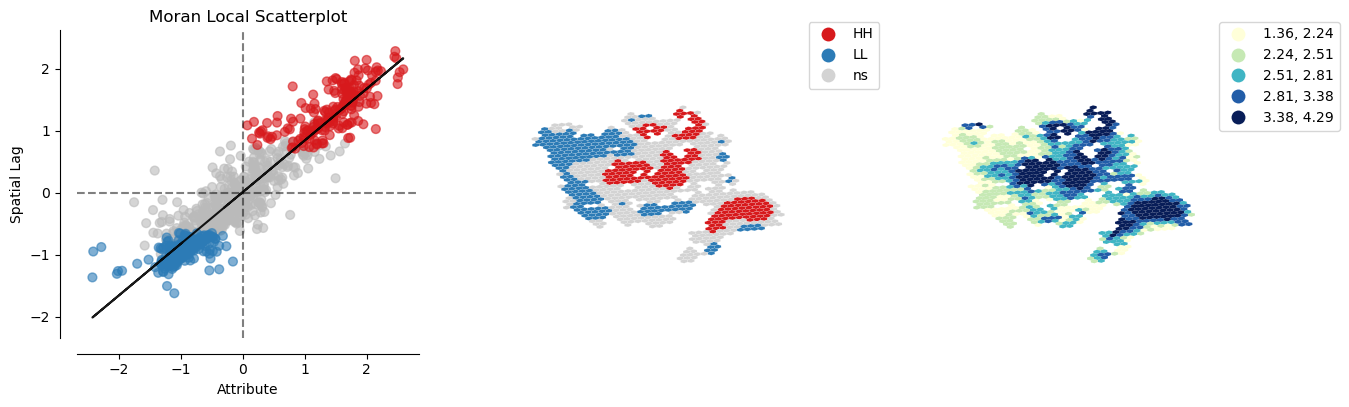

In [97]:
plot_local_autocorrelation(lisa, gdf, 'mean');
#Left: Moran Local scatter plot, 
# Middle: Lisa cluster map with statistically significant HH, LH, LL, HL, (p value is 0.05 by default)
# Right: Mean from data